In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

2026-05-09 09:29:45.800383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778318986.065222      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778318986.141295      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778318986.745374      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778318986.745430      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778318986.745433      16 computation_placer.cc:177] computation placer alr

In [2]:
model = load_model(
    "/kaggle/input/models/mistblade69/resnetmobilenet-mods/keras/default/1/tumor_mobilenetv2_image.keras"
)

test_dir=r"/kaggle/input/datasets/mistblade69/brisc-dataset2025/brisc2025/classification_task/test"

2026-05-09 09:30:18.345095: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1000 images belonging to 4 classes.


In [4]:
y_pred_probs = model.predict(test_dataset)

y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true = test_dataset.classes

class_names = list(test_dataset.class_indices.keys())

print("Predictions Complete")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1778319022.701615      58 service.cc:152] XLA service 0x78f60400cdf0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778319022.701746      58 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1778319024.629373      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 215s 7s/step
Predictions Complete


In [5]:
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

report_df.to_csv(
    "/kaggle/working/mobilenet_classification_report.csv",
    index=True
)

              precision    recall  f1-score   support
glioma         0.979275  0.744094  0.845638   254.000
meningioma     0.832117  0.745098  0.786207   306.000
no_tumor       0.767956  0.992857  0.866044   140.000
pituitary      0.846591  0.993333  0.914110   300.000
accuracy       0.854000  0.854000  0.854000     0.854
macro avg      0.856485  0.868846  0.853000  1000.000
weighted avg   0.864855  0.854000  0.850850  1000.000


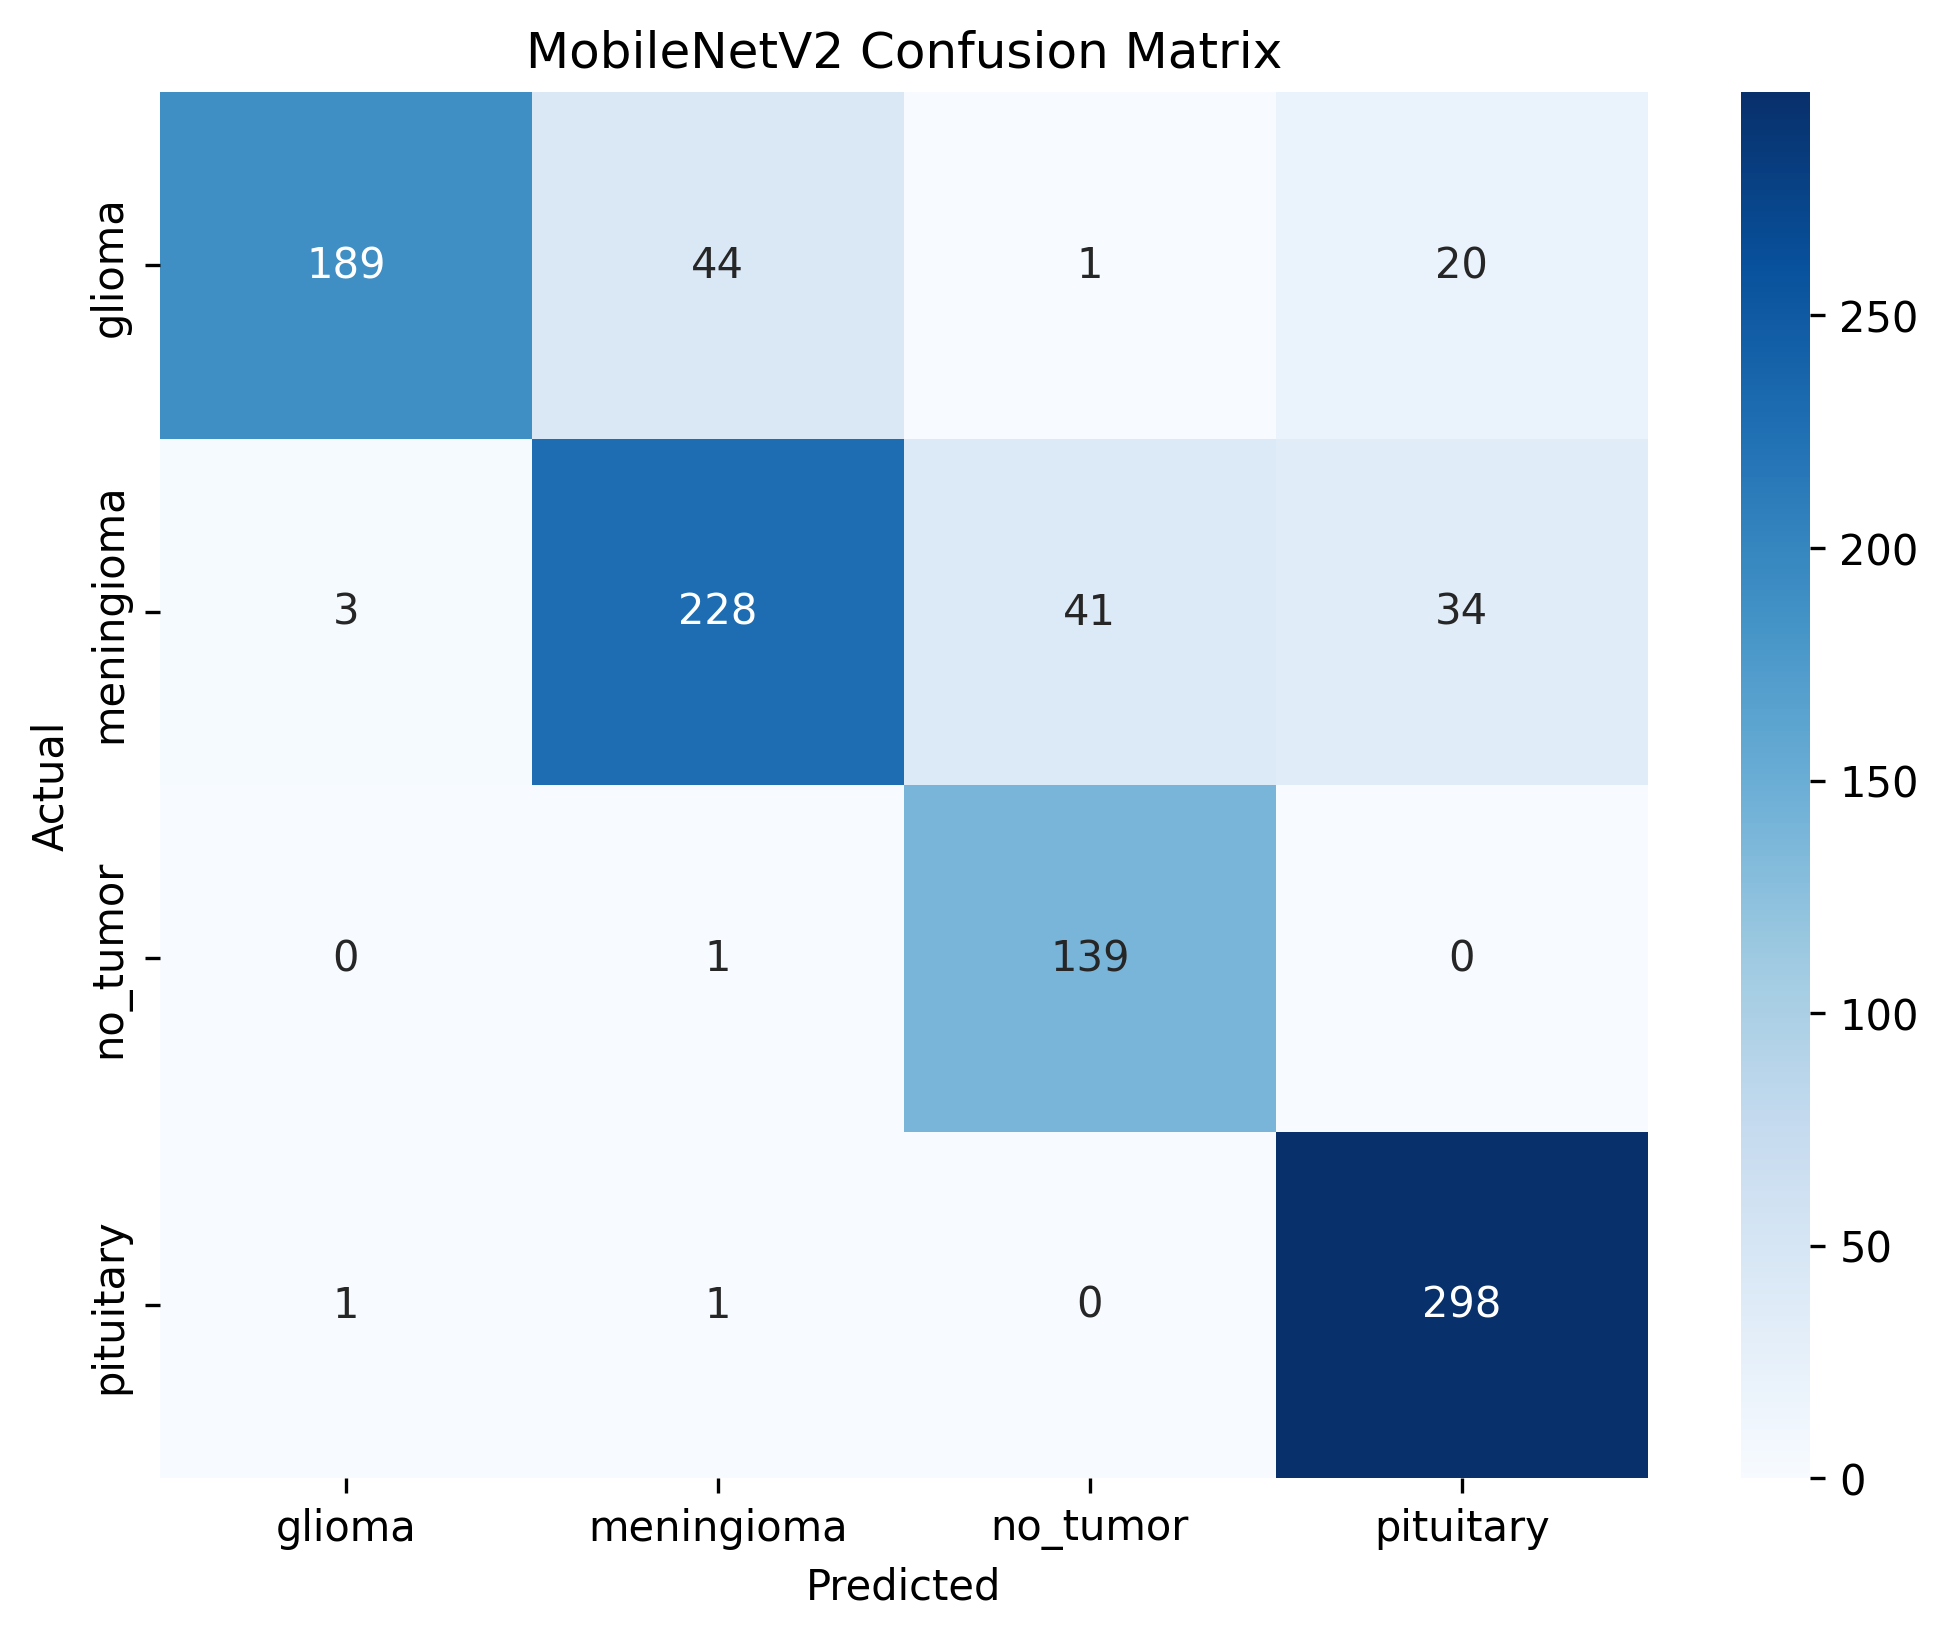

In [6]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(8,6), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "MobileNetV2 Confusion Matrix"
)

plt.savefig(
    "/kaggle/working/mobilenet_confusion_matrix.png",
    bbox_inches='tight',
    dpi=300
)

plt.show()

In [7]:
y_true_bin = label_binarize(
    y_true,
    classes=np.unique(y_true)
)

auc_score = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.9811162210439134


In [8]:
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

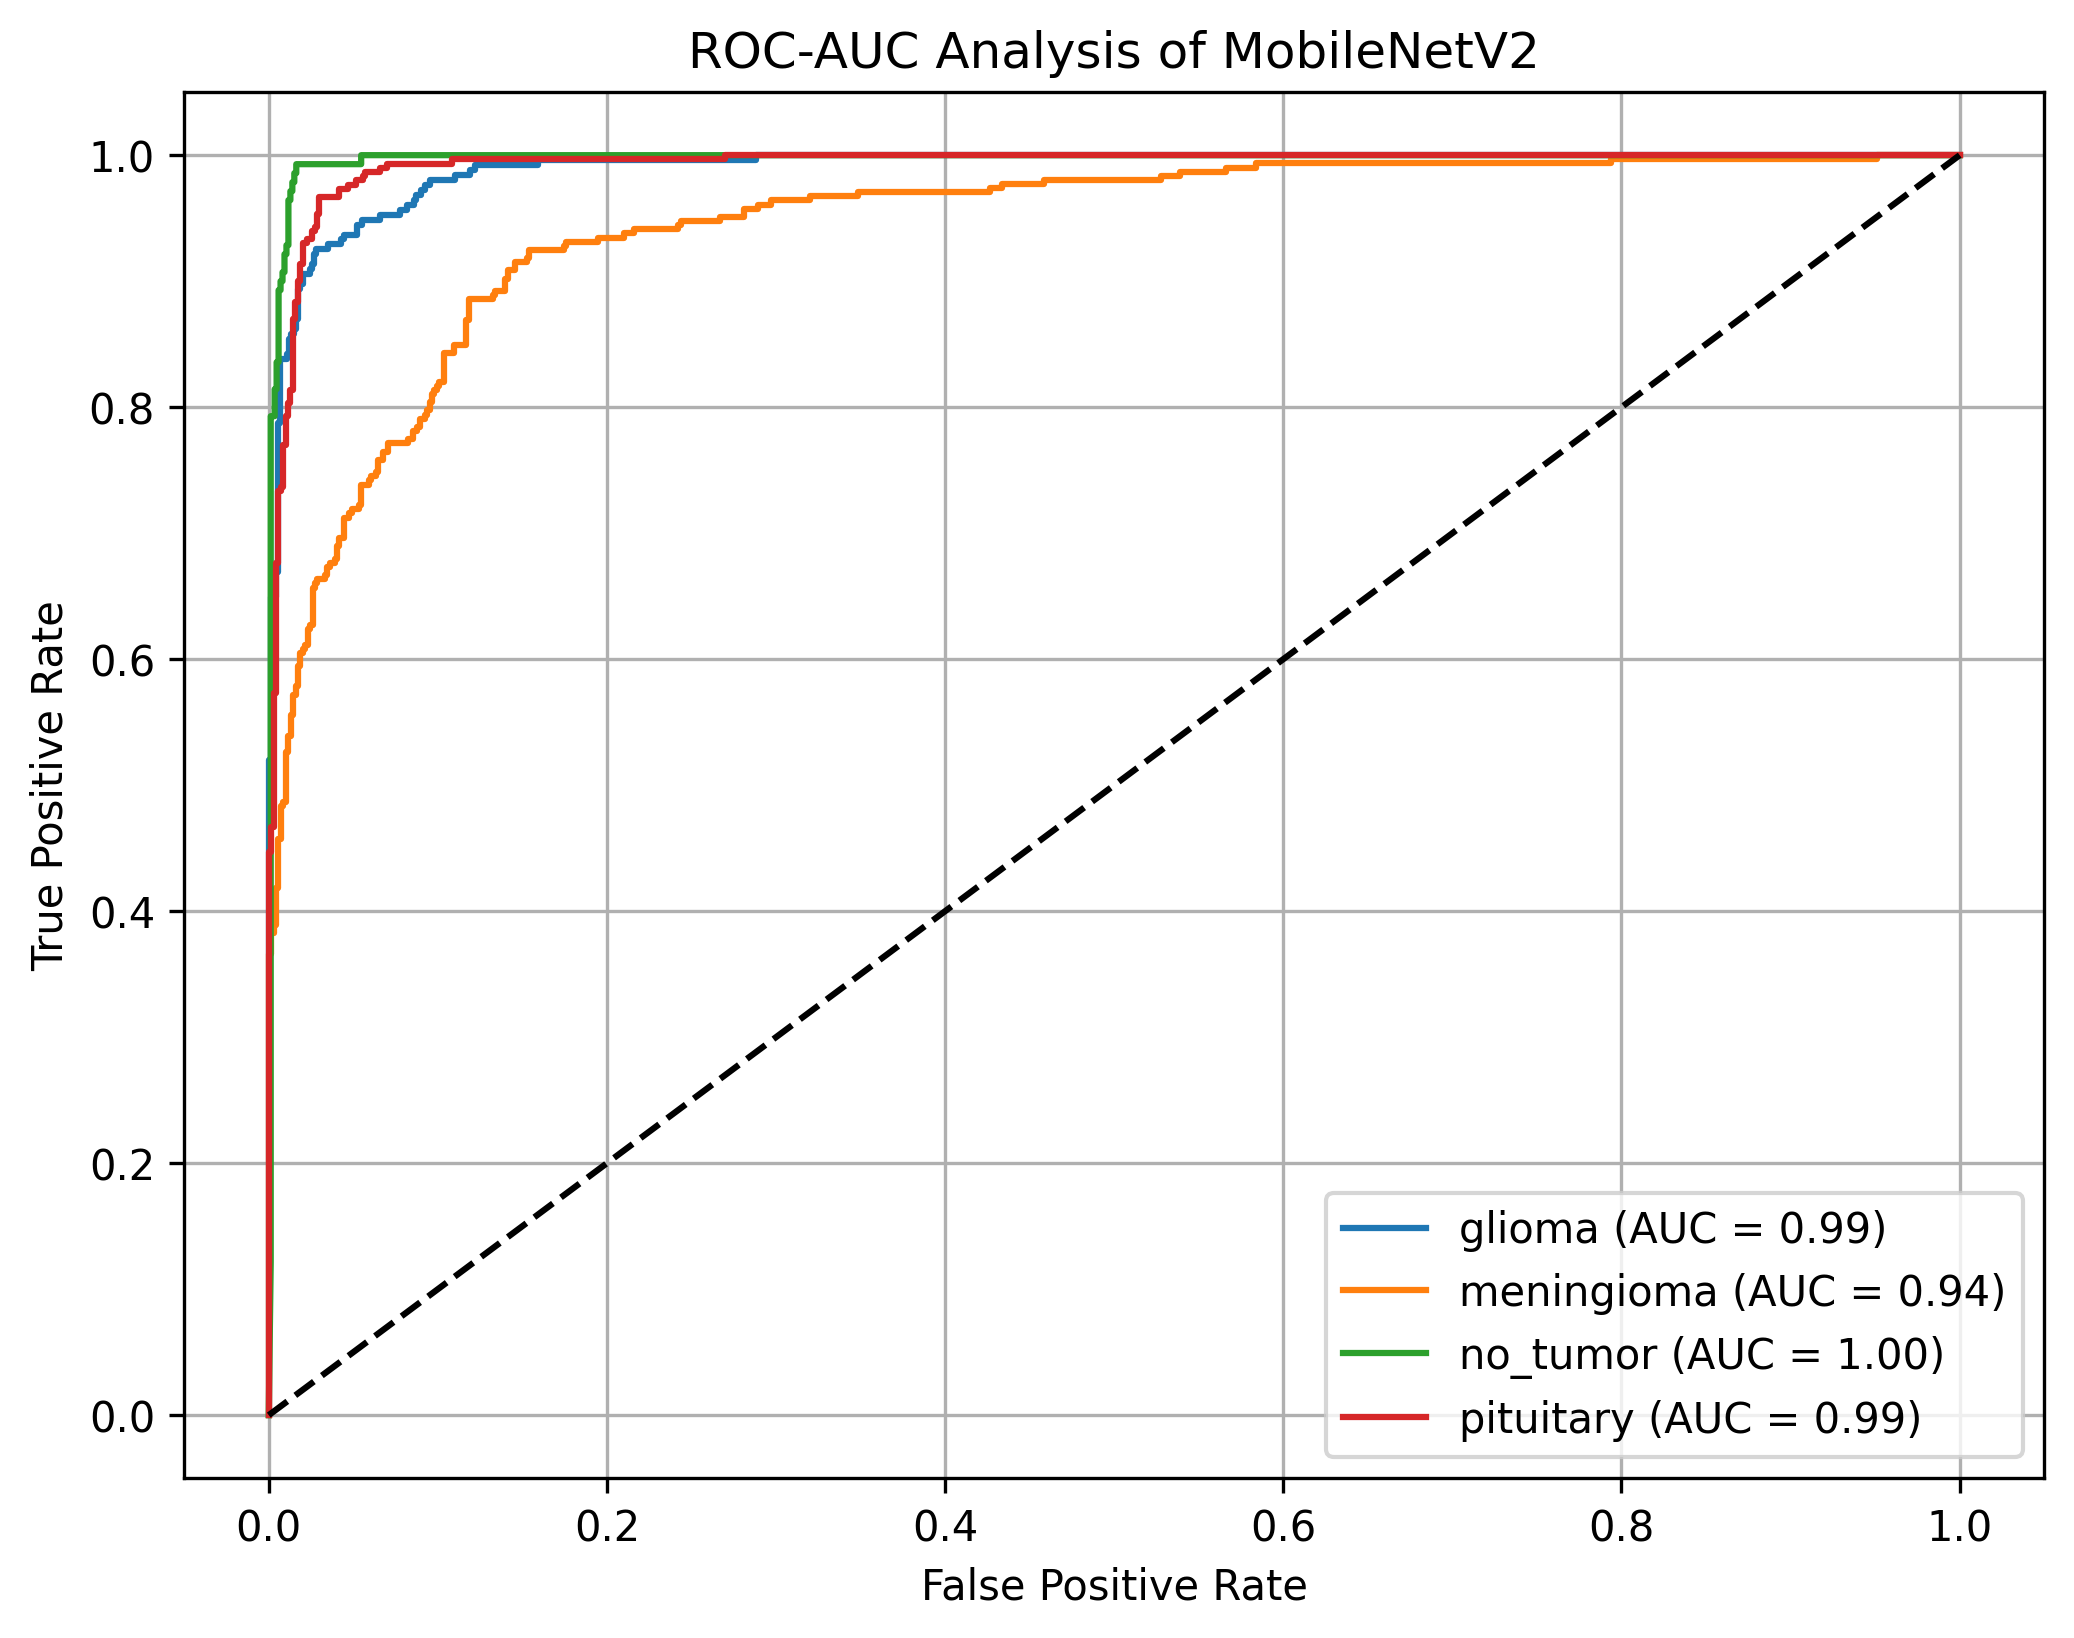

In [9]:
plt.figure(figsize=(8,6), dpi=300)

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'ROC-AUC Analysis of MobileNetV2'
)

plt.legend(loc='lower right')

plt.grid(True)

plt.savefig(
    "/kaggle/working/mobilenet_roc_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
params = model.count_params()

print("Total Parameters:", params)

Total Parameters: 2592068


In [11]:
start_time = time.time()

model.predict(test_dataset)

end_time = time.time()

total_time = end_time - start_time

avg_time = (
    total_time /
    len(test_dataset.filenames)
)

print("Total Inference Time:", total_time)

print("Average Time Per Image:", avg_time)

32/32 ━━━━━━━━━━━━━━━━━━━━ 206s 6s/step
Total Inference Time: 205.99866485595703
Average Time Per Image: 0.20599866485595703


In [12]:
with open(
    "/kaggle/working/mobilenet_metrics.txt",
    "w"
) as f:

    f.write(f"ROC-AUC: {auc_score}\n")
    f.write(f"Parameters: {params}\n")
    f.write(f"Total Inference Time: {total_time}\n")
    f.write(f"Average Time Per Image: {avg_time}\n")

print("Metrics Saved")

Metrics Saved


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Accuracy
accuracy = accuracy_score(
    y_true,
    y_pred_classes
)

# Precision
precision = precision_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

# Recall
recall = recall_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

# F1 Score
f1 = f1_score(
    y_true,
    y_pred_classes,
    average='weighted'
)

# ROC-AUC
y_true_bin = label_binarize(
    y_true,
    classes=np.unique(y_true)
)

roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)


Accuracy: 0.854
Precision: 0.864854573403583
Recall: 0.854
F1 Score: 0.8508504914069114
ROC-AUC: 0.9811162210439134


In [14]:
# Create metrics dataframe

metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print(metrics_df)

      Metric     Value
0   Accuracy  0.854000
1  Precision  0.864855
2     Recall  0.854000
3   F1 Score  0.850850
4    ROC-AUC  0.981116


In [15]:
# Save metrics

metrics_df.to_csv(
    "/kaggle/working/mobilenet_evaluation_metrics.csv",
    index=False
)

print("Metrics CSV saved.")

Metrics CSV saved.


In [16]:
# Save text metrics

with open(
    "/kaggle/working/mobilenet_evaluation_metrics.txt",
    "w"
) as f:

    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1 Score: {f1}\n")
    f.write(f"ROC-AUC: {roc_auc}\n")

print("Metrics TXT saved.")

Metrics TXT saved.
